In [37]:
import os

import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg, col, explode, expr, lit, regexp_replace
from pyspark.sql.functions import round as spark_round
from pyspark.sql.functions import split
from pyspark.sql.functions import sum as spark_sum
from pyspark.sql.functions import udf, when
from pyspark.sql.types import (
    DateType,
    DoubleType,
    IntegerType,
    StringType,
    StructField,
    StructType,
)
from pyspark.sql import Window
from pyspark.sql.functions import row_number
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display, Markdown

In [21]:
# Set the schema
listing_schema = StructType(
    [
        StructField("id", StringType(), True),
        StructField("name", StringType(), True),
        StructField("host_id", StringType(), True),
        StructField("host_name", StringType(), True),
        StructField("neighbourhood_group", StringType(), True),
        StructField("neighbourhood", StringType(), True),
        StructField("latitude", DoubleType(), True),
        StructField("longitude", DoubleType(), True),
        StructField("room_type", StringType(), True),
        StructField("price", DoubleType(), True),
        StructField("minimum_nights", IntegerType(), True),
        StructField("number_of_reviews", IntegerType(), True),
        StructField("last_review", DateType(), True),
        StructField("reviews_per_month", DoubleType(), True),
        StructField("calculated_host_listings_count", IntegerType(), True),
        StructField("availability_365", IntegerType(), True),
        StructField("number_of_reviews_ltm", IntegerType(), True),
        StructField("license", StringType(), True),
    ]
)

In [22]:
base_dir = "/mnt/data/public/insideairbnb/data.insideairbnb.com/united-states"
states = os.listdir(base_dir)
state_cities = {
    state: [city for city in os.listdir(os.path.join(base_dir, state))]
    for state in states
}
state_cities

{'nc': ['asheville'],
 'tx': ['austin', 'dallas', 'fort-worth'],
 'ma': ['boston', 'cambridge'],
 'il': ['chicago'],
 'nv': ['clark-county-nv'],
 'oh': ['columbus'],
 'co': ['denver'],
 'ca': ['los-angeles',
  'oakland',
  'pacific-grove',
  'san-diego',
  'san-francisco',
  'san-mateo-county',
  'santa-clara-county',
  'santa-cruz-county'],
 'fl': ['broward-county'],
 'hi': ['hawaii'],
 'nj': ['jersey-city', 'newark'],
 'tn': ['nashville'],
 'la': ['new-orleans'],
 'ny': ['new-york-city', 'albany', 'rochester'],
 'or': ['portland', 'salem-or'],
 'ri': ['rhode-island'],
 'wa': ['seattle'],
 'mn': ['twin-cities-msa'],
 'dc': ['washington-dc'],
 'mt': ['bozeman']}

In [13]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import lit
import os

spark = SparkSession.builder.appName("Airbnb").getOrCreate()

city_dfs = {}
start_year = 2015

for state, cities in state_cities.items():
    for city in cities:

        print(state, city)

        df_data_list = []
        city_base_dir = os.path.join(base_dir, state, city)

        # Filter folders that start with a valid year
        year_folders = [
            f for f in os.listdir(city_base_dir)
            if f[:4].isdigit() and int(f[:4]) >= start_year
        ]

        for year_folder in sorted(year_folders):

            data_filepath = os.path.join(
                city_base_dir,
                year_folder,
                "visualisations",
                "listings.csv"
            )

            # Read csv
            df_data = spark.read.csv(
                data_filepath,
                header=True,
                schema=listing_schema
            )

            # Extract year & month from folder name
            if "-" in year_folder:
                year, month, date = year_folder.split("-")
                df_data = df_data \
                    .withColumn("year", lit(int(year))) \
                    .withColumn("month", lit(int(month))) \
                    .withColumn("date", lit(int(date)))
            else:
                df_data = df_data \
                    .withColumn("year", lit(int(year_folder))) \
                    .withColumn("month", lit(None)) \
                    .withColumn("date", lit(None))

            df_data_list.append(df_data)

        # Combine the data
        df_data_combined = df_data_list[0]
        for df in df_data_list[1:]:
            df_data_combined = df_data_combined.unionByName(df)

        city_dfs[city] = df_data_combined

        #print(f"Loaded {city} with {df_data_combined.count()} rows")

nc asheville
tx austin
tx dallas
tx fort-worth
ma boston
ma cambridge
il chicago
nv clark-county-nv
oh columbus
co denver
ca los-angeles
ca oakland
ca pacific-grove
ca san-diego
ca san-francisco
ca san-mateo-county
ca santa-clara-county
ca santa-cruz-county
fl broward-county
hi hawaii
nj jersey-city
nj newark
tn nashville
la new-orleans
ny new-york-city
ny albany
ny rochester
or portland
or salem-or
ri rhode-island
wa seattle
mn twin-cities-msa
dc washington-dc
mt bozeman


In [25]:
csv_path = "data/city_monthly_cache.csv"
mean_path = "data/mean_monthly_cache.csv"

city_monthly = []

# if csv exists, just read
if os.path.exists(csv_path) and os.path.exists(mean_path):
    all_data = pd.read_csv(csv_path, parse_dates=["date"])
    mean_df = pd.read_csv(mean_path, parse_dates=["date"])

    # Re-create city_monthly structure
    for city in all_data["city"].unique():
        pdf = all_data[all_data["city"] == city].copy()
        city_monthly.append((city, pdf))

# if not, compute and save
else:
    all_city_frames = []  # for CSV saving

    for city, df in city_dfs.items():
        print(city)

        pdf = (
            df.groupBy("year", "month", "date")
            .avg("price")
            .orderBy("year", "month", "date")
            .toPandas()
        )

        pdf["date"] = pd.to_datetime(
            pdf["year"].astype(str) + "-"
            + pdf["month"].astype(str) + "-"
            + pdf["date"].astype(str)
        )

        pdf["city"] = city

        city_monthly.append((city, pdf))
        all_city_frames.append(pdf)

    # Combine all cities
    all_data = pd.concat(all_city_frames, ignore_index=True)

    # Compute overall mean
    mean_df = (
        all_data.groupby("date")["avg(price)"]
        .mean()
        .reset_index()
    )

    # Save both to csv
    all_data.to_csv(csv_path, index=False)
    mean_df.to_csv(mean_path, index=False)

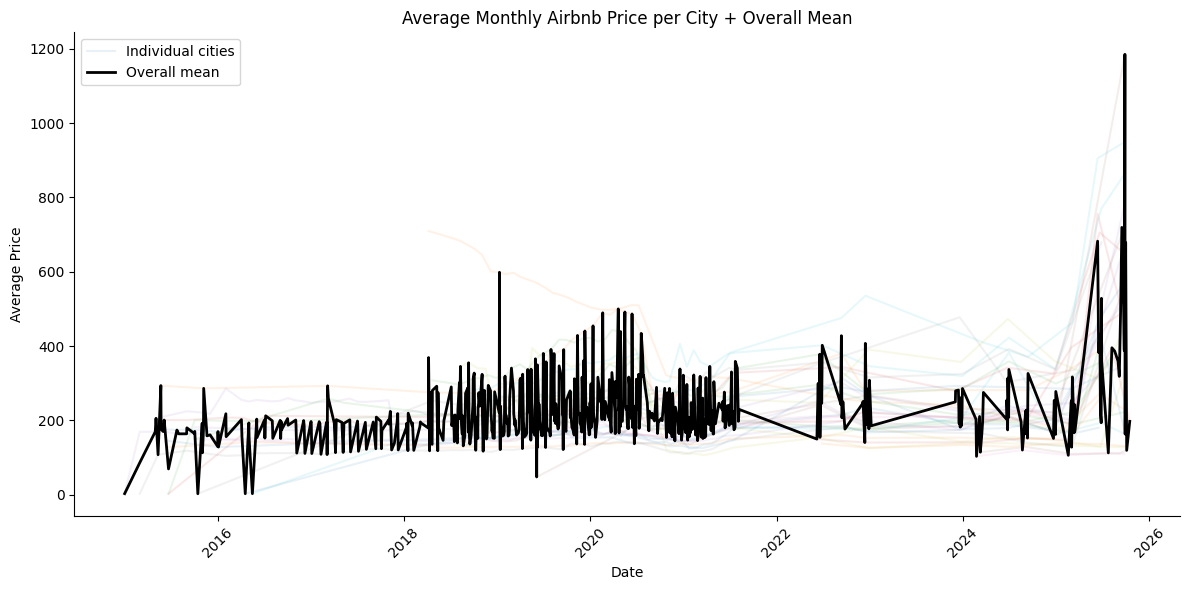

**Figure X.** Average Monthly Airbnb Price per City with the Mean Across Cities

In [39]:
plt.figure(figsize=(12,6))

for city, pdf in city_monthly:
    plt.plot(pdf["date"], pdf["avg(price)"], alpha=0.1)

# Mean line
plt.plot(mean_df["date"], mean_df["avg(price)"], linewidth=2, color="black")

plt.title("Average Monthly Airbnb Price per City + Overall Mean")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

# Add a legend
legend_elements = [
    Line2D([0], [0], label='Individual cities', alpha=0.1),
    Line2D([0], [0], label='Overall mean', linewidth=2, color="black"),
]
plt.legend(handles=legend_elements)

plt.show()

display(Markdown('**Figure X.** Average Monthly Airbnb '
                 'Price per City with the Mean Across Cities'))